In [ ]:
!pip install torch torchvision timm scikit-learn matplotlib pandas
!pip install timm

In [2]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit, GroupKFold

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/עיבוד תמונה בכלים של למידה עמוקה-חן וירין/project/MendeleyData_USBreast"

benign_path = os.path.join(base_path, "Benign")
malignant_path = os.path.join(base_path, "Malignant")

print(os.listdir(benign_path)[:5])
print(os.listdir(malignant_path)[:5])

['us34.bmp', 'us44.bmp', 'us33.bmp', 'us20.bmp', 'us25.bmp']
['us104.bmp', 'us106.bmp', 'us105.bmp', 'us102.bmp', 'us101.bmp']


In [5]:
data = []

def extract_number(path):
    filename = os.path.basename(path)
    return int(re.findall(r'\d+', filename)[0])

def add_folder(folder, label):
    paths = glob.glob(os.path.join(folder, "*.bmp"))
    paths = sorted(paths, key=extract_number)

    for p in paths:
        num = extract_number(p)
        patient_id = (num - 1) // 5   # 5 images per patient

        data.append({
            "path": p,
            "label": label,
            "group": f"{folder}_{patient_id}"  # prevent mixing folders
        })

add_folder(benign_path, 0)
add_folder(malignant_path, 1)

df = pd.DataFrame(data)

print(df.head())
print("Total images:", len(df))
print("Patients:", df["group"].nunique())

                                                path  label  \
0  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   
1  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   
2  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   
3  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   
4  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   

                                               group  
0  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...  
1  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...  
2  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...  
3  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...  
4  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...  
Total images: 250
Patients: 50


In [6]:
print(df["label"].value_counts())
print(df.groupby("label")["group"].nunique())

label
1    150
0    100
Name: count, dtype: int64
label
0    20
1    30
Name: group, dtype: int64


In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

train_val_idx, test_idx = next(
    gss.split(df, df["label"], groups=df["group"])
)

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

tiny_df = train_val_df.sample(n=20, random_state=42).reset_index(drop=True)

print("Train+Val images:", len(train_val_df))
print("Test images:", len(test_df))

print("Train+Val patients:", train_val_df["group"].nunique())
print("Test patients:", test_df["group"].nunique())

Train+Val images: 210
Test images: 40
Train+Val patients: 42
Test patients: 8


In [8]:
def print_distribution_percent(name, data):
    counts = data["label"].value_counts().sort_index()
    total = len(data)

    print(f"\n{name}")
    print("-" * 30)
    print(f"Benign (0): {counts.get(0, 0)} ({counts.get(0, 0)/total:.2%})")
    print(f"Malignant (1): {counts.get(1, 0)} ({counts.get(1, 0)/total:.2%})")
    print(f"Total: {total}")


print_distribution_percent("TRAIN+VAL SET", train_val_df)
print_distribution_percent("TEST SET", test_df)


TRAIN+VAL SET
------------------------------
Benign (0): 90 (42.86%)
Malignant (1): 120 (57.14%)
Total: 210

TEST SET
------------------------------
Benign (0): 10 (25.00%)
Malignant (1): 30 (75.00%)
Total: 40


In [9]:
class BreastDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")
        label = torch.tensor(row["label"]).long()

        if self.transform:
            img = self.transform(img)

        return img, label

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

tiny_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [11]:
path = "/content/drive/MyDrive/עיבוד תמונה בכלים של למידה עמוקה-חן וירין/project/DenseNet121.pt"

print(os.path.exists(path))

True


In [12]:
checkpoint = torch.load(
    path,
    map_location="cpu"
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [13]:
def get_radimagenet_densenet():

    model = models.densenet121(
        weights=None
    )

    checkpoint = torch.load(
        "/content/drive/MyDrive/עיבוד תמונה בכלים של למידה עמוקה-חן וירין/project/DenseNet121.pt",
        map_location="cpu"
    )


    new_checkpoint = {}

    for key, value in checkpoint.items():

        new_key = key.replace(
            "backbone.0.",
            "features."
        )

        new_checkpoint[new_key] = value


    missing_keys, unexpected_keys = model.load_state_dict(
        new_checkpoint,
        strict=False
    )
    model.classifier = nn.Linear(model.classifier.in_features,2)

    print("Missing keys:")
    print(missing_keys)

    print("\nUnexpected keys:")
    print(unexpected_keys)


    return model

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(out, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss/len(loader), correct/total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss/len(loader), correct/total

In [15]:
tiny_loader = DataLoader(
    BreastDataset(tiny_df, tiny_transform),
    batch_size=4,
    shuffle=True
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_radimagenet_densenet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]


In [17]:
for epoch in range(50):

    model.train()

    total_loss, correct, total = 0, 0, 0

    for x, y in tiny_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = correct / total

    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Acc={acc:.4f}")

Epoch 1: Loss=3.4772, Acc=0.5000
Epoch 2: Loss=3.3713, Acc=0.7000
Epoch 3: Loss=3.2420, Acc=0.6000
Epoch 4: Loss=3.0959, Acc=0.6000
Epoch 5: Loss=2.9299, Acc=0.7000
Epoch 6: Loss=2.9997, Acc=0.6000
Epoch 7: Loss=2.6287, Acc=0.7000
Epoch 8: Loss=2.2200, Acc=0.8500
Epoch 9: Loss=1.8946, Acc=0.9500
Epoch 10: Loss=2.0663, Acc=0.8500
Epoch 11: Loss=1.8066, Acc=0.9000
Epoch 12: Loss=2.5701, Acc=0.8500
Epoch 13: Loss=1.5352, Acc=0.9000
Epoch 14: Loss=1.3437, Acc=0.9500
Epoch 15: Loss=1.8130, Acc=0.8000
Epoch 16: Loss=1.2558, Acc=0.9000
Epoch 17: Loss=0.9729, Acc=0.9500
Epoch 18: Loss=1.2723, Acc=0.9500
Epoch 19: Loss=0.9469, Acc=0.9500
Epoch 20: Loss=2.2267, Acc=0.8000
Epoch 21: Loss=0.7315, Acc=1.0000
Epoch 22: Loss=0.3932, Acc=1.0000
Epoch 23: Loss=0.7815, Acc=1.0000
Epoch 24: Loss=2.1781, Acc=0.8500
Epoch 25: Loss=0.6976, Acc=1.0000
Epoch 26: Loss=0.4635, Acc=1.0000
Epoch 27: Loss=0.5937, Acc=0.9500
Epoch 28: Loss=0.5575, Acc=1.0000
Epoch 29: Loss=0.3131, Acc=1.0000
Epoch 30: Loss=0.1607, 

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gkf = GroupKFold(n_splits=5)

fold_histories = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(train_val_df,
              train_val_df["label"],
              groups=train_val_df["group"])
):

    print(f"\n===== FOLD {fold+1} =====")

    train_df = train_val_df.iloc[train_idx]
    val_df = train_val_df.iloc[val_idx]

    # Labels in the current training fold
    train_labels = train_df["label"].values

    # Compute class weights
    weights = compute_class_weight(class_weight="balanced",classes=np.array([0, 1]),y=train_labels)
    class_weights = torch.tensor(weights, dtype=torch.float).to(device)

    print("Class weights:", class_weights)

    train_loader = DataLoader(BreastDataset(train_df, transform),
                              batch_size=16, shuffle=True)

    val_loader = DataLoader(BreastDataset(val_df, transform),
                            batch_size=16, shuffle=False)

    model = get_radimagenet_densenet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    epochs = 10

    tr_loss_list, val_loss_list = [], []
    tr_acc_list, val_acc_list = [], []

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        tr_loss_list.append(tr_loss)
        val_loss_list.append(val_loss)
        tr_acc_list.append(tr_acc)
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={tr_acc:.3f}, Val Acc={val_acc:.3f}")

    fold_histories.append((tr_loss_list, val_loss_list, tr_acc_list, val_acc_list))


===== FOLD 1 =====
Class weights: tensor([1.1786, 0.8684], device='cuda:0')
Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]
Epoch 1: Train Acc=0.600, Val Acc=0.667
Epoch 2: Train Acc=0.812, Val Acc=0.733
Epoch 3: Train Acc=0.752, Val Acc=0.600
Epoch 4: Train Acc=0.818, Val Acc=0.689
Epoch 5: Train Acc=0.855, Val Acc=0.756
Epoch 6: Train Acc=0.855, Val Acc=0.711
Epoch 7: Train Acc=0.830, Val Acc=0.622
Epoch 8: Train Acc=0.891, Val Acc=0.578
Epoch 9: Train Acc=0.915, Val Acc=0.689
Epoch 10: Train Acc=0.915, Val Acc=0.867

===== FOLD 2 =====
Class weights: tensor([1.1786, 0.8684], device='cuda:0')
Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]
Epoch 1: Train Acc=0.333, Val Acc=0.289
Epoch 2: Train Acc=0.624, Val Acc=0.778
Epoch 3: Train Acc=0.758, Val Acc=0.822
Epoch 4: Train Acc=0.788, Val Acc=0.867
Epoch 5: Train Acc=0.842, Val Acc=0.911
Epoch 6: Train Acc=0.830, Val Acc=0.867
Epoch 7: Train Acc=0.867, Val Acc=0.933
Epoch 8: Trai

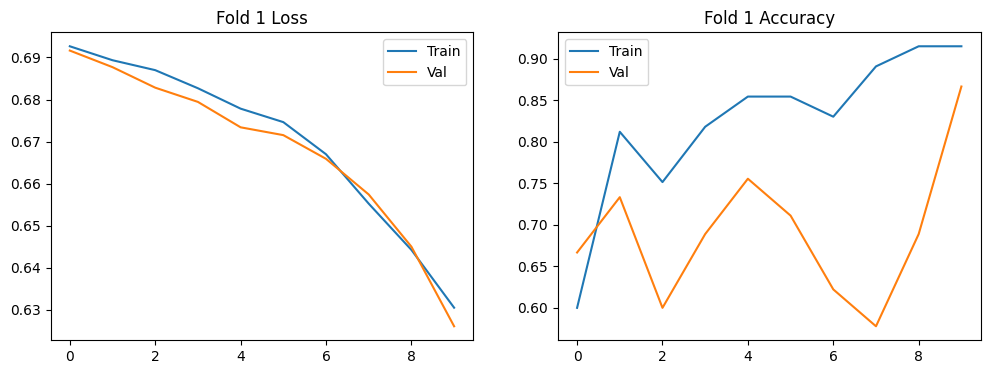

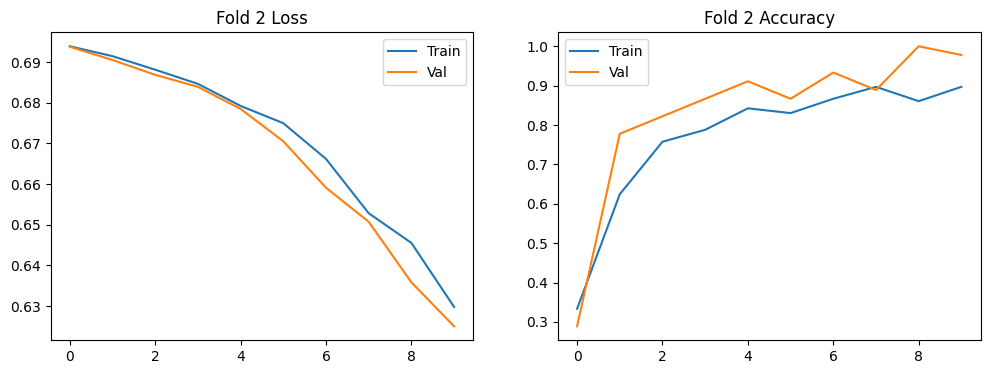

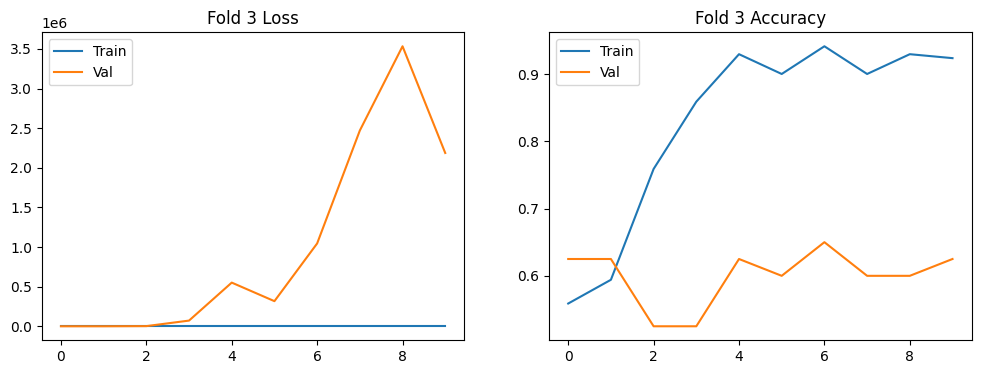

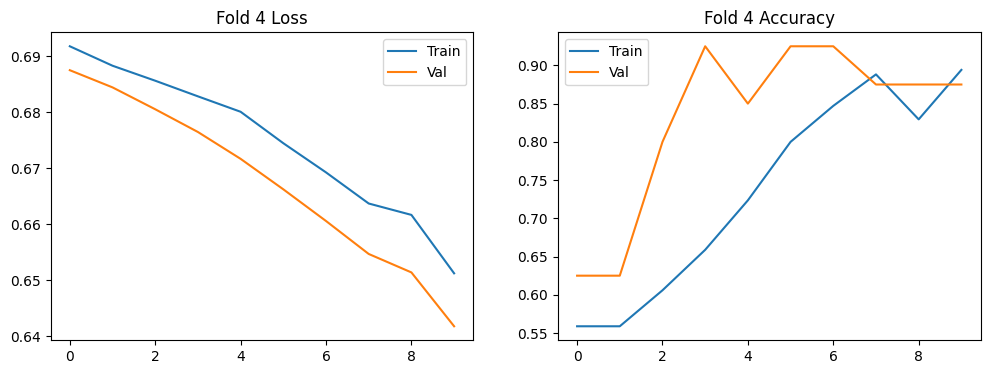

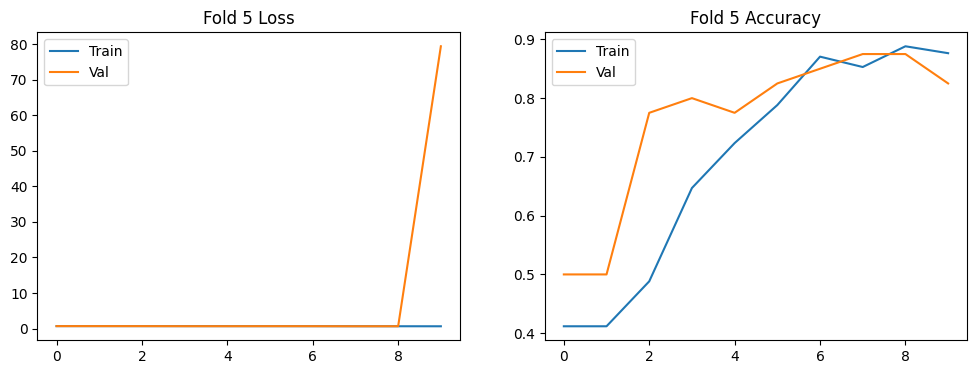

In [19]:
for i, (tr_l, val_l, tr_a, val_a) in enumerate(fold_histories):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(tr_l, label="Train")
    plt.plot(val_l, label="Val")
    plt.title(f"Fold {i+1} Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(tr_a, label="Train")
    plt.plot(val_a, label="Val")
    plt.title(f"Fold {i+1} Accuracy")
    plt.legend()

    plt.show()

In [20]:
final_train_df = train_val_df

In [21]:
final_train_loader = DataLoader(
    BreastDataset(final_train_df, transform),
    batch_size=16,
    shuffle=True)

test_transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_loader = DataLoader(
    BreastDataset(test_df, test_transform),
    batch_size=16,
    shuffle=False
)

In [22]:
final_model = get_radimagenet_densenet().to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]


In [23]:
best_val_loss = float("inf")
patience = 7
counter = 0
train_losses = []
train_accs = []

best_model_path = "final_model.pth"

for epoch in range(50):

    train_loss, train_acc = train_one_epoch(
        final_model,
        final_train_loader,
        optimizer,
        criterion,
        device
    )

    # NOTE: no validation split here — we use training loss as proxy
    # (or you can create a small internal validation split if you want)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Save best model based on training loss (simple version)
    if train_loss < best_val_loss:
        best_val_loss = train_loss
        counter = 0
        torch.save(final_model.state_dict(), best_model_path)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (final training)")
            break


Epoch 1: Train Loss=0.6909, Train Acc=0.4286
Epoch 2: Train Loss=0.6871, Train Acc=0.5286
Epoch 3: Train Loss=0.6825, Train Acc=0.6810
Epoch 4: Train Loss=0.6774, Train Acc=0.7095
Epoch 5: Train Loss=0.6655, Train Acc=0.7905
Epoch 6: Train Loss=0.6548, Train Acc=0.8476
Epoch 7: Train Loss=0.6392, Train Acc=0.8762
Epoch 8: Train Loss=0.6266, Train Acc=0.9048
Epoch 9: Train Loss=0.6011, Train Acc=0.8952
Epoch 10: Train Loss=0.5804, Train Acc=0.9143
Epoch 11: Train Loss=0.5684, Train Acc=0.9000
Epoch 12: Train Loss=0.5437, Train Acc=0.9190
Epoch 13: Train Loss=0.5232, Train Acc=0.9190
Epoch 14: Train Loss=0.5010, Train Acc=0.9143
Epoch 15: Train Loss=0.4813, Train Acc=0.9333
Epoch 16: Train Loss=0.4578, Train Acc=0.9381
Epoch 17: Train Loss=0.4223, Train Acc=0.9190
Epoch 18: Train Loss=0.3915, Train Acc=0.9095
Epoch 19: Train Loss=0.3602, Train Acc=0.9571
Epoch 20: Train Loss=0.3643, Train Acc=0.9476
Epoch 21: Train Loss=0.3693, Train Acc=0.9286
Epoch 22: Train Loss=0.3393, Train Acc=0.94

In [24]:
final_model.load_state_dict(torch.load(best_model_path))

<All keys matched successfully>

In [25]:
final_model.eval()

test_loss, test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device
)

print("FINAL TEST ACCURACY:", test_acc)
print("FINAL TEST LOSS:", test_loss)

FINAL TEST ACCURACY: 0.875
FINAL TEST LOSS: 0.30611908187468845


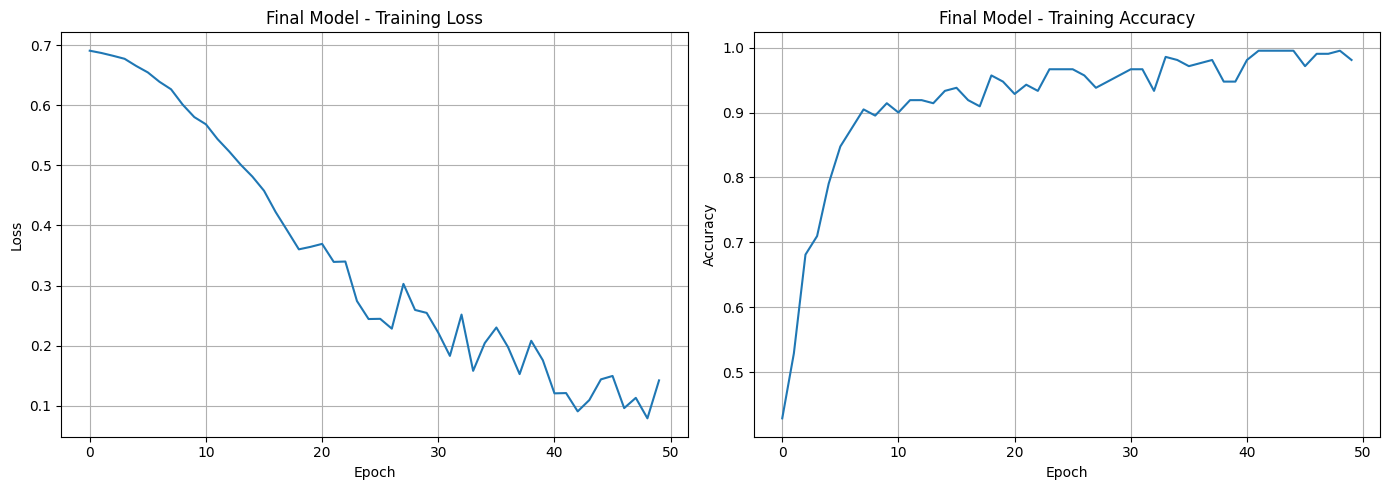

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses)
axes[0].set_title("Final Model - Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs)
axes[1].set_title("Final Model - Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()

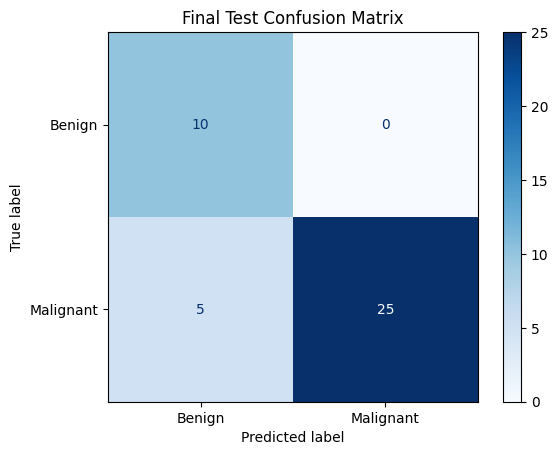

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [27]:

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = final_model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Final Test Confusion Matrix")
plt.show()


final_model.eval()


In [28]:
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.67      1.00      0.80        10
   Malignant       1.00      0.83      0.91        30

    accuracy                           0.88        40
   macro avg       0.83      0.92      0.85        40
weighted avg       0.92      0.88      0.88        40



In [29]:
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = final_model(images)

        # Convert logits to probabilities
        probs = torch.softmax(outputs, dim=1)

        # Probability of malignant (class = 1)
        malignant_probs = probs[:, 1]

        y_true.extend(labels.numpy())
        y_scores.extend(malignant_probs.cpu().numpy())

In [30]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.4f}")

AUC = 0.9500


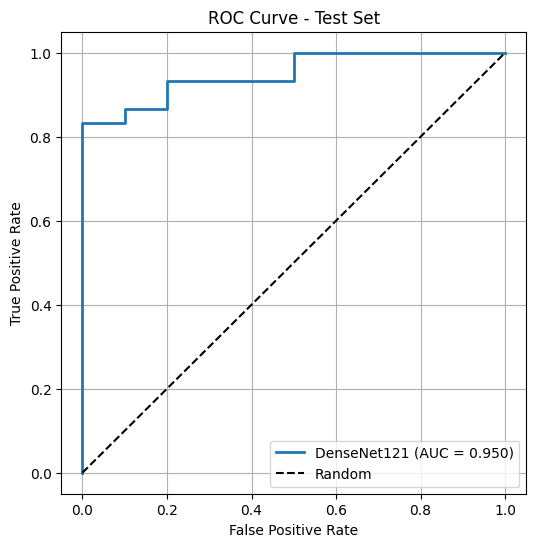

In [31]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f"DenseNet121 (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")

plt.legend()
plt.grid(True)

plt.show()